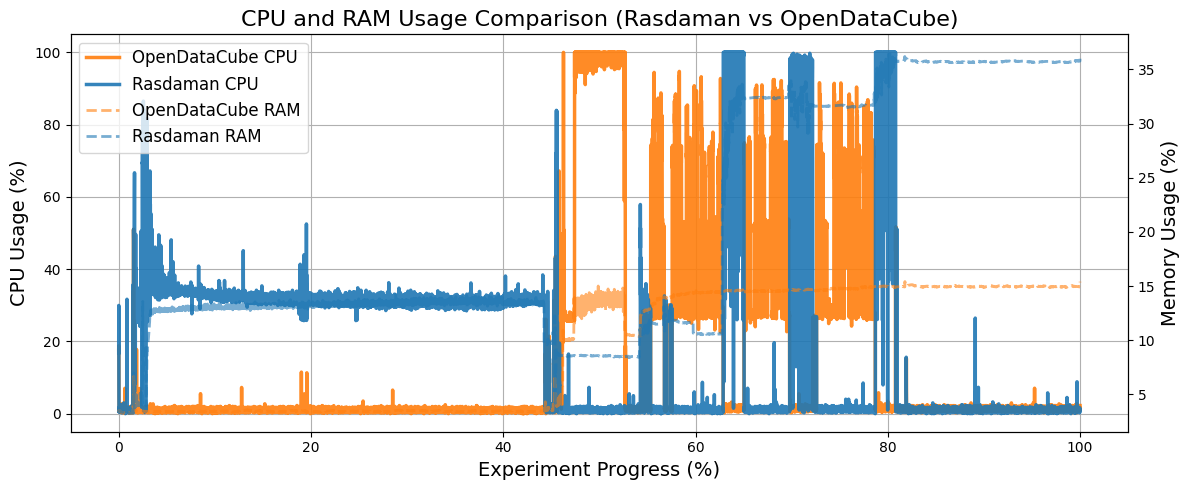

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_PATH = "metrics"

RUNS = [1]
SYSTEMS = {
    "OpenDataCube": "odc_sut",
    "Rasdaman": "rasdaman_sut"
}

COLORS = {
    "OpenDataCube": "#ff7f0e",  # orange
    "Rasdaman": "#1f77b4"       # blue
}

def add_progress(df):
    df = df.sort_values("timestamp")
    df["progress"] = np.linspace(0, 100, len(df))
    return df

def process_cpu(df):
    df["cpu_used"] = 100 - df["cpu_idle"]
    return df[["timestamp", "cpu_used"]]

def process_mem(df):
    df["mem_used"] = 100 - df["mem_available"]
    return df[["timestamp", "mem_used"]]

def load_system(system_folder):
    cpu_runs = []
    mem_runs = []

    for run in RUNS:
        path = os.path.join(BASE_PATH, f"run{run}", system_folder)

        # --- CPU ---
        cpu = pd.read_csv(os.path.join(path, "cpu_metrics.csv"))
        cpu = process_cpu(cpu)

        # --- MEM ---
        mem = pd.read_csv(os.path.join(path, "mem_metrics.csv"))
        mem = process_mem(mem)

        # --- ALIGN CPU + MEM within the same run ---
        min_len = min(len(cpu), len(mem))
        cpu = cpu.iloc[:min_len].reset_index(drop=True)
        mem = mem.iloc[:min_len].reset_index(drop=True)

        df = pd.DataFrame({
            "cpu_used": cpu["cpu_used"],
            "mem_used": mem["mem_used"]
        })

        df["progress"] = np.linspace(0, 100, len(df))

        cpu_runs.append(df)

    # --- ALIGN across runs ---
    min_len = min(len(df) for df in cpu_runs)
    aligned = [df.iloc[:min_len].reset_index(drop=True) for df in cpu_runs]

    combined = pd.concat(aligned).groupby(level=0).mean()

    return combined

platform_curves = {}


for name, folder in SYSTEMS.items():
    df = load_system(folder)

    platform_curves[name] = {
        "progress": df["progress"],
        "cpu_used": df["cpu_used"],
        "mem_used": df["mem_used"]
    }

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

for name, data in platform_curves.items():
    color = COLORS.get(name, "#333333")

    # CPU (strong)
    ax1.plot(
        data["progress"],
        data["cpu_used"],
        label=f"{name} CPU",
        color=color,
        linewidth=2.5,
        linestyle="-",
        alpha=0.9
    )

    # RAM (lighter)
    ax2.plot(
        data["progress"],
        data["mem_used"],
        label=f"{name} RAM",
        color=color,
        linewidth=2,
        linestyle="--",
        alpha=0.6
    )

# Labels
ax1.set_xlabel("Experiment Progress (%)", fontsize=14)
ax1.set_ylabel("CPU Usage (%)", fontsize=14)
ax2.set_ylabel("Memory Usage (%)", fontsize=14)

plt.title("CPU and RAM Usage Comparison (Rasdaman vs OpenDataCube)", fontsize=16)

ax1.grid(True)

# Combined legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, fontsize=12)

plt.tight_layout()
plt.savefig("cpu_ram_combined.pdf", bbox_inches='tight')
plt.show()

OpenDataCube 23327
Rasdaman 23309


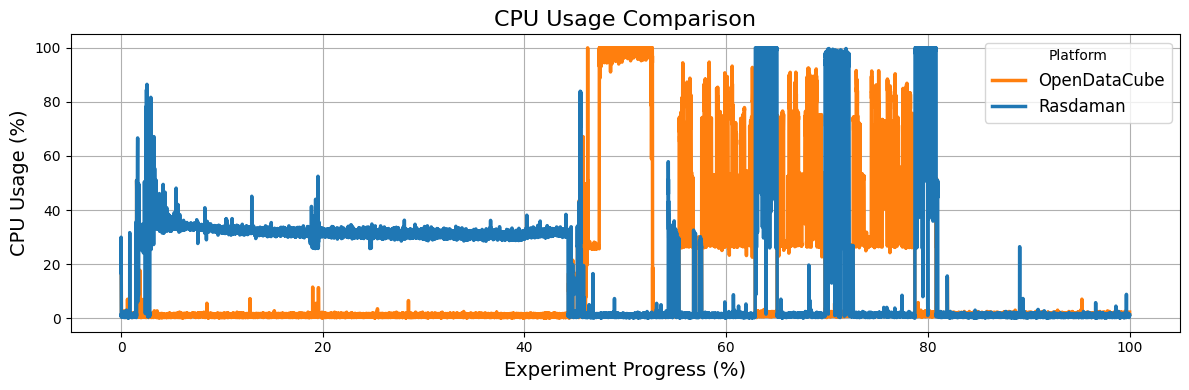

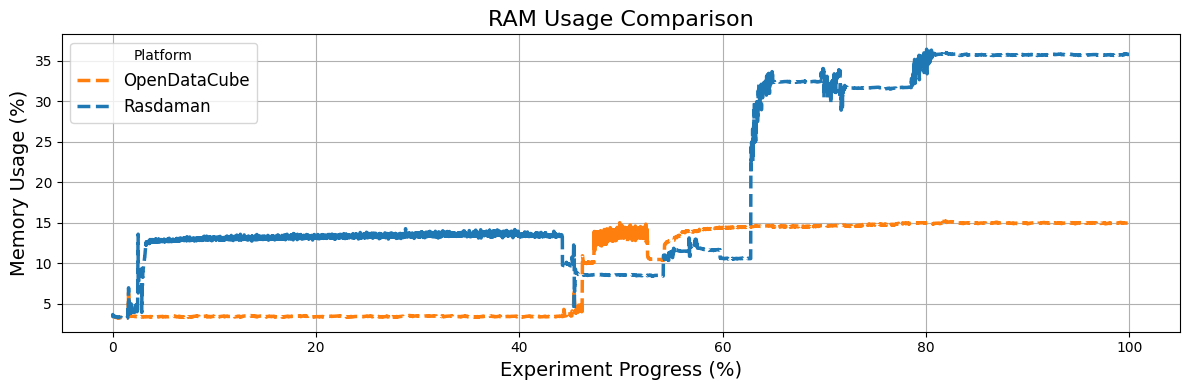

In [6]:
#separated graphs
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_PATH = "metrics"

RUNS = [1]

SYSTEMS = {
    "OpenDataCube": "odc_sut",
    "Rasdaman": "rasdaman_sut"
}

COLORS = {
    "OpenDataCube": "#ff7f0e",  # orange
    "Rasdaman": "#1f77b4"       # blue
}

def process_cpu(df):
    df["cpu_used"] = 100 - df["cpu_idle"]
    return df[["cpu_used"]]

def process_mem(df):
    df["mem_used"] = 100 - df["mem_available"]
    return df[["mem_used"]]

def load_system(system_folder):
    runs_data = []

    for run in RUNS:
        path = os.path.join(BASE_PATH, f"run{run}", system_folder)

        cpu_path = os.path.join(path, "cpu_metrics.csv")
        mem_path = os.path.join(path, "mem_metrics.csv")

        if not os.path.exists(cpu_path) or not os.path.exists(mem_path):
            print(f"Skipping {system_folder} run{run} (missing files)")
            continue

        cpu = pd.read_csv(cpu_path)
        mem = pd.read_csv(mem_path)

        cpu = process_cpu(cpu)
        mem = process_mem(mem)

        # --- Align CPU + MEM within run ---
        min_len = min(len(cpu), len(mem))
        cpu = cpu.iloc[:min_len].reset_index(drop=True)
        mem = mem.iloc[:min_len].reset_index(drop=True)

        df = pd.DataFrame({
            "cpu_used": cpu["cpu_used"],
            "mem_used": mem["mem_used"]
        })

        df["progress"] = np.linspace(0, 100, len(df))

        runs_data.append(df)

    if not runs_data:
        raise ValueError(f"No valid runs found for {system_folder}")

    # --- Align across runs ---
    min_len = min(len(df) for df in runs_data)
    aligned = [df.iloc[:min_len].reset_index(drop=True) for df in runs_data]

    combined = pd.concat(aligned).groupby(level=0).mean()

    return combined

platform_curves = {}

for name, folder in SYSTEMS.items():
    df = load_system(folder)

    platform_curves[name] = {
        "progress": df["progress"],
        "cpu_used": df["cpu_used"],
        "mem_used": df["mem_used"]
    }

# Sanity check
for name, data in platform_curves.items():
    print(name, len(data["progress"]))

fig, ax = plt.subplots(figsize=(12, 4))

for name, data in platform_curves.items():
    color = COLORS.get(name, "#333333")

    ax.plot(
        data["progress"],
        data["cpu_used"],
        label=name,
        color=color,
        linewidth=2.5
    )

ax.set_title("CPU Usage Comparison", fontsize=16)
ax.set_xlabel("Experiment Progress (%)", fontsize=14)
ax.set_ylabel("CPU Usage (%)", fontsize=14)

ax.grid(True)
ax.legend(title="Platform", fontsize=12)

plt.tight_layout()
plt.savefig("cpu_usage_comparison.pdf", bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))

for name, data in platform_curves.items():
    color = COLORS.get(name, "#333333")

    ax.plot(
        data["progress"],
        data["mem_used"],
        label=name,
        color=color,
        linewidth=2.5,
        linestyle="--"   # visually distinguish from CPU style
    )

ax.set_title("RAM Usage Comparison", fontsize=16)
ax.set_xlabel("Experiment Progress (%)", fontsize=14)
ax.set_ylabel("Memory Usage (%)", fontsize=14)

ax.grid(True)
ax.legend(title="Platform", fontsize=12)

plt.tight_layout()
plt.savefig("ram_usage_comparison.pdf", bbox_inches='tight')
plt.show()